# Augmentation ablation script

**Goal:** instead of one combined pipeline that randomly mixes every degradation together, define each augmentation technique as its own independent, parameterized function. Apply techniques **one at a time** to selected images, export the results, then test each set in `prompt_optimisation.ipynb`.

**Analogy:** this is an *ablation study*. The combined pipeline (`augmentation_pipeline.py`) is like testing a car on a rough road with rain, wind, and bumps all at once — realistic, but if performance drops you can't tell which factor caused it. Here, we change **one variable at a time**, so any change in tampering-detection accuracy can be attributed to a specific technique (e.g. "JPEG compression alone drops recall by X%").

## Output layout

For each selected image and each selected technique, one augmented file is written to `test_images_augmented/by_technique/`, named `<original_stem>_<technique_name><suffix>` (e.g. `payslip1_jpeg_compression.jpeg`). Each output inherits the ground-truth label of its source image in `image_labels.json`.

## 1. Setup

In [2]:
import os

os.environ.setdefault("NO_ALBUMENTATIONS_UPDATE", "1")

from pathlib import Path
from typing import Callable

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
from augraphy import ShadowCast

from result_logger import get_image_label, set_image_label

In [3]:
def load_document_image(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb


def show_comparison(
    original_image: np.ndarray,
    augmented_image: np.ndarray,
    augmented_title: str,
) -> None:
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_image)
    axes[0].set_title("original")
    axes[0].axis("off")
    axes[1].imshow(augmented_image)
    axes[1].set_title(augmented_title)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


def show_grid(
    images: list[np.ndarray],
    titles: list[str],
    n_cols: int = 3,
) -> None:
    n_images = len(images)
    n_rows = (n_images + n_cols - 1) // n_cols
    figure, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes_flat = axes.flatten()
    for axis, image, title in zip(axes_flat, images, titles):
        axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")
    for axis in axes_flat[n_images:]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## 2. Independent augmentation functions

Each function takes an RGB image (and technique-specific parameters with sensible defaults) and returns the augmented RGB image. Every transform uses `p=1.0` so the technique is *always* applied — for an ablation study we want "did this technique run or not" to be a choice we make explicitly, not a coin flip.

### Geometric

In [4]:
def apply_rotation(
    image_rgb: np.ndarray,
    limit: tuple[float, float] = (-5, 5),
) -> np.ndarray:
    """Slight rotation: misaligned page placement on the scanner bed."""
    transform = A.Rotate(limit=limit, border_mode=cv2.BORDER_CONSTANT, fill=255, p=1.0)
    return transform(image=image_rgb)["image"]


def apply_perspective_warp(
    image_rgb: np.ndarray,
    scale: tuple[float, float] = (0.02, 0.05),
) -> np.ndarray:
    """Perspective/affine warp: slight keystoning from a non-flat scanning bed."""
    transform = A.Perspective(scale=scale, fill=255, p=1.0)
    return transform(image=image_rgb)["image"]


def apply_elastic_distortion(
    image_rgb: np.ndarray,
    alpha: float = 15,
    sigma: float = 8,
) -> np.ndarray:
    """Minor elastic distortion: paper curl near the edges."""
    transform = A.ElasticTransform(
        alpha=alpha, sigma=sigma, border_mode=cv2.BORDER_CONSTANT, fill=255, p=1.0
    )
    return transform(image=image_rgb)["image"]


def apply_crop_and_pad(
    image_rgb: np.ndarray,
    crop_fraction: float = 0.92,
) -> np.ndarray:
    """Random crop + pad: scanner not capturing the full page edges."""
    image_height, image_width = image_rgb.shape[:2]
    cropped_height = int(image_height * crop_fraction)
    cropped_width = int(image_width * crop_fraction)

    transform = A.Compose(
        [
            A.RandomCrop(height=cropped_height, width=cropped_width, p=1.0),
            A.PadIfNeeded(
                min_height=image_height,
                min_width=image_width,
                position="random",
                border_mode=cv2.BORDER_CONSTANT,
                fill=255,
                p=1.0,
            ),
        ]
    )
    return transform(image=image_rgb)["image"]

### Photometric

In [5]:
def apply_jpeg_compression(
    image_rgb: np.ndarray,
    quality_range: tuple[int, int] = (60, 85),
) -> np.ndarray:
    """JPEG compression artifacts: scan-to-PDF pipeline degradation."""
    transform = A.ImageCompression(compression_type="jpeg", quality_range=quality_range, p=1.0)
    return transform(image=image_rgb)["image"]


def apply_gaussian_blur(
    image_rgb: np.ndarray,
    blur_limit: tuple[int, int] = (3, 5),
) -> np.ndarray:
    """Gaussian blur: out-of-focus scanner."""
    transform = A.GaussianBlur(blur_limit=blur_limit, p=1.0)
    return transform(image=image_rgb)["image"]

### Scanning-specific (augraphy)

`augraphy` augmentations operate on `BGR` arrays, so these functions convert in and out internally — every function in this notebook takes RGB in and returns RGB out, regardless of which library implements it.

In [6]:
def apply_shadow_vignette(
    image_rgb: np.ndarray,
    shadow_opacity_range: tuple[float, float] = (0.2, 0.5),
) -> np.ndarray:
    """Shadow vignetting at edges: light falloff from the scanner lid."""
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    augmentation = ShadowCast(shadow_side="random", shadow_opacity_range=shadow_opacity_range, p=1.0)
    augmented_bgr = augmentation(image_bgr)
    return cv2.cvtColor(augmented_bgr, cv2.COLOR_BGR2RGB)

## 3. Registry

Maps a technique name (used in output filenames) to its function. This is the single place to add new techniques or remove ones you don't want to test.

In [7]:
AUGMENTATION_FUNCTIONS: dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "rotation": apply_rotation,
    "perspective": apply_perspective_warp,
    "elastic_distortion": apply_elastic_distortion,
    "crop_and_pad": apply_crop_and_pad,
    "jpeg_compression": apply_jpeg_compression,
    "gaussian_blur": apply_gaussian_blur,
    "shadow_vignette": apply_shadow_vignette
}

## 4. Preview each technique on one sample image

Before running the full export, sanity-check that every technique looks reasonable on a sample document.

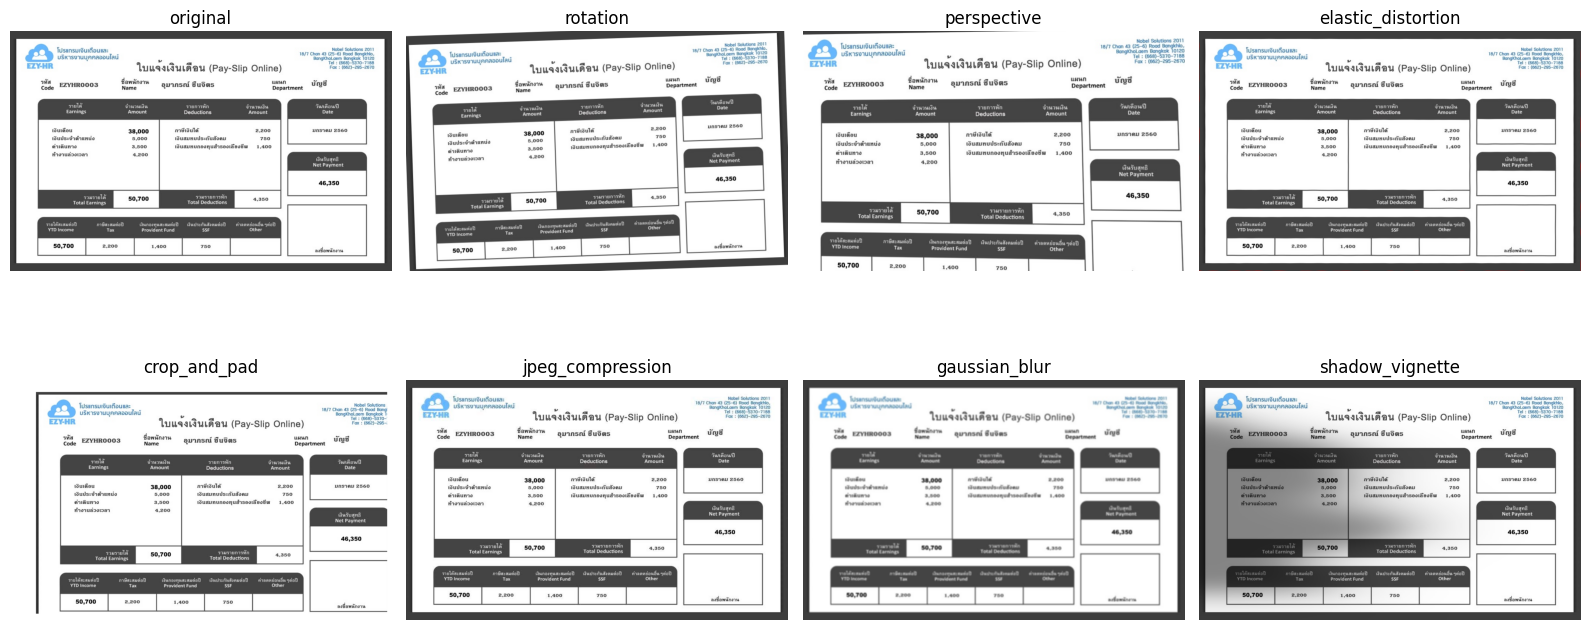

In [8]:
preview_image = load_document_image(Path("test_images/payslip1.jpeg"))

preview_images = [preview_image] + [
    augmentation_function(preview_image) for augmentation_function in AUGMENTATION_FUNCTIONS.values()
]
preview_titles = ["original"] + list(AUGMENTATION_FUNCTIONS.keys())

show_grid(preview_images, preview_titles, n_cols=4)

## 5. Run the ablation export

For each selected image path and each selected technique, apply that technique alone, save the result, and register its label in `image_labels.json` (copied from the source image).

In [9]:
def augment_selected_images(
    image_paths: list[str],
    augmentation_functions: dict[str, Callable[[np.ndarray], np.ndarray]],
    output_dir: Path,
) -> list[str]:
    """Apply each augmentation function on its own to every image in `image_paths`.

    Writes one output file per (image, technique) combination to `output_dir`,
    named "<source_stem>_<technique_name><source_suffix>". Each output inherits
    the ground-truth label and label_signals of its source image, if present in
    image_labels.json, and is tagged with `augmentation=<technique_name>` so
    `load_results()` can group experiment results by technique.

    Returns the list of output paths created, as strings matching the
    `image_path` format used elsewhere (e.g. in `paths` and image_labels.json).
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    output_paths: list[str] = []

    for image_path_str in image_paths:
        image_path = Path(image_path_str)
        label, label_signals, _ = get_image_label(image_path_str)
        image_rgb = load_document_image(image_path)

        for technique_name, augmentation_function in augmentation_functions.items():
            augmented_rgb = augmentation_function(image_rgb)
            augmented_bgr = cv2.cvtColor(augmented_rgb, cv2.COLOR_RGB2BGR)

            output_path = output_dir / f"{image_path.stem}_{technique_name}{image_path.suffix}"
            cv2.imwrite(str(output_path), augmented_bgr)

            output_key = str(output_path)
            if label is not None:
                set_image_label(output_key, label, label_signals, augmentation=technique_name)

            output_paths.append(output_key)
            print(f"saved {output_key}")

    return output_paths

In [10]:
# Pick which images to run the ablation on.
selected_image_paths = ["test_images/payslip10.jpeg",
    "test_images/payslip1.jpeg",
    "test_images/payslip20.png",
    "test_images/payslip3.png",
]

# Pick which techniques to run -- use a subset of AUGMENTATION_FUNCTIONS to
# focus on specific effects, or pass AUGMENTATION_FUNCTIONS directly for all of them.
selected_augmentations = AUGMENTATION_FUNCTIONS

output_dir = Path("test_images_augmented/by_technique")

output_paths = augment_selected_images(selected_image_paths, selected_augmentations, output_dir)
print(f"created {len(output_paths)} images")

saved test_images_augmented/by_technique/payslip10_rotation.jpeg
saved test_images_augmented/by_technique/payslip10_perspective.jpeg
saved test_images_augmented/by_technique/payslip10_elastic_distortion.jpeg
saved test_images_augmented/by_technique/payslip10_crop_and_pad.jpeg
saved test_images_augmented/by_technique/payslip10_jpeg_compression.jpeg
saved test_images_augmented/by_technique/payslip10_gaussian_blur.jpeg
saved test_images_augmented/by_technique/payslip10_shadow_vignette.jpeg
saved test_images_augmented/by_technique/payslip1_rotation.jpeg
saved test_images_augmented/by_technique/payslip1_perspective.jpeg
saved test_images_augmented/by_technique/payslip1_elastic_distortion.jpeg
saved test_images_augmented/by_technique/payslip1_crop_and_pad.jpeg
saved test_images_augmented/by_technique/payslip1_jpeg_compression.jpeg
saved test_images_augmented/by_technique/payslip1_gaussian_blur.jpeg
saved test_images_augmented/by_technique/payslip1_shadow_vignette.jpeg
saved test_images_augme

In [11]:
output_paths

['test_images_augmented/by_technique/payslip10_rotation.jpeg',
 'test_images_augmented/by_technique/payslip10_perspective.jpeg',
 'test_images_augmented/by_technique/payslip10_elastic_distortion.jpeg',
 'test_images_augmented/by_technique/payslip10_crop_and_pad.jpeg',
 'test_images_augmented/by_technique/payslip10_jpeg_compression.jpeg',
 'test_images_augmented/by_technique/payslip10_gaussian_blur.jpeg',
 'test_images_augmented/by_technique/payslip10_shadow_vignette.jpeg',
 'test_images_augmented/by_technique/payslip1_rotation.jpeg',
 'test_images_augmented/by_technique/payslip1_perspective.jpeg',
 'test_images_augmented/by_technique/payslip1_elastic_distortion.jpeg',
 'test_images_augmented/by_technique/payslip1_crop_and_pad.jpeg',
 'test_images_augmented/by_technique/payslip1_jpeg_compression.jpeg',
 'test_images_augmented/by_technique/payslip1_gaussian_blur.jpeg',
 'test_images_augmented/by_technique/payslip1_shadow_vignette.jpeg',
 'test_images_augmented/by_technique/payslip20_rota

## Next steps

- In `run_experiments.ipynb`, build a new `paths` list from `output_paths` (or specific entries from `test_images_augmented/by_technique/`) and run the usual experiment loop.
- `load_results()` now adds an `augmentation` column (joined from `image_labels.json`), so you can compare detection accuracy per technique directly: `df_all.groupby("augmentation").apply(compute_binary_metrics)`.
- To test a single technique in isolation, pass a one-entry dict to `augment_selected_images`, e.g. `{"jpeg_compression": apply_jpeg_compression}`.
- To test a technique at a different strength, call the function directly with different parameters, e.g. `apply_jpeg_compression(image_rgb, quality_range=(30, 50))` for more aggressive compression.